# Olist E-commerce Analytics Pipeline

End-to-end data analytics project using Python, PostgreSQL and Power BI.

Author: Ivan Santiago Quintero

## Business Objective

The objective of this project is to analyze Olist's e-commerce operations and build a dimensional model suitable for business intelligence.

The project includes:

- Data exploration
- Data cleaning
- Star schema design
- ETL construction
- PostgreSQL implementation
- Power BI dashboard

## Business Understanding

Olist is one of the largest Brazilian e-commerce marketplaces, connecting customers with thousands of independent sellers across different product categories.

The dataset represents the complete purchase lifecycle, from customer orders and payments to product reviews and deliveries.

### Main Business Entities

- **Customers:** End users who place orders on the platform.
- **Orders:** Transactions made by customers.
- **Order Items:** Individual products purchased within each order.
- **Products:** Product catalog and specifications.
- **Sellers:** Merchants responsible for fulfilling orders.
- **Payments:** Payment methods and transaction values.
- **Reviews:** Customer satisfaction after receiving products.

### Business Process

1. A customer places an order.
2. Each order may contain one or multiple products.
3. Each product is sold by a specific seller.
4. The customer completes the payment.
5. The seller ships the products.
6. The customer receives the order and can leave a review.

This workflow naturally defines **Order Items** as the lowest level of granularity, making it the most appropriate choice for the fact table in the dimensional model.

## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load datasets

In [4]:
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

## Initial Exploration

The Olist dataset is composed of nine interconnected tables representing customers, products, sellers, orders and payments.

In [5]:
customers.info()
customers.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [6]:
geolocation.info()
geolocation.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [7]:
order_items.info()
order_items.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [8]:
order_items['order_item_id'].nunique()

21

In [9]:
order_items.duplicated( subset = ['order_id', 'order_item_id']).sum() # It seems that primary key consists of 2 columns

np.int64(0)

In [10]:
order_payments.info()
order_payments.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [11]:
order_reviews.info()
order_reviews.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [12]:
orders.info()
orders.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [13]:
products.info()
products.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [14]:
sellers.info()
sellers.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [15]:
category.info()
category.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


## Data Understanding

**Tables**

* Customers: Customers information

  Registers: 99441. Pk: customer_id. Fk: customer_zip_code_prefix

* Geolocation: Coordenates and zip code information

  Registers: 1000163. Pk: none. Fk: none.

* Order_items: Sales by items

  Registers: 112650. Pk: (order_id, order_item_id). Fk: product_id, seller_id

* Order_payments: Payment descriptions

  Registers: 103886. Pk: none. Fk: order_id

* Order_reviews: Ratings and reviews

  Registers: 99224. Pk: review_id. Fk: order_id

* Orders: Sales in general (not by items)

  Registers: 99441. Pk: order_id. Fk: customer_id

* Products: Product specifications

  Registers: 32951. Pk: product_id. Fk: product_category_name

* Seller: Seller info

  Registers: 3095. Pk: seller_id. Fk: zip_code_seller

* Category: Category translations

  Registers: 71. Pk: product_category_name. Fk: none

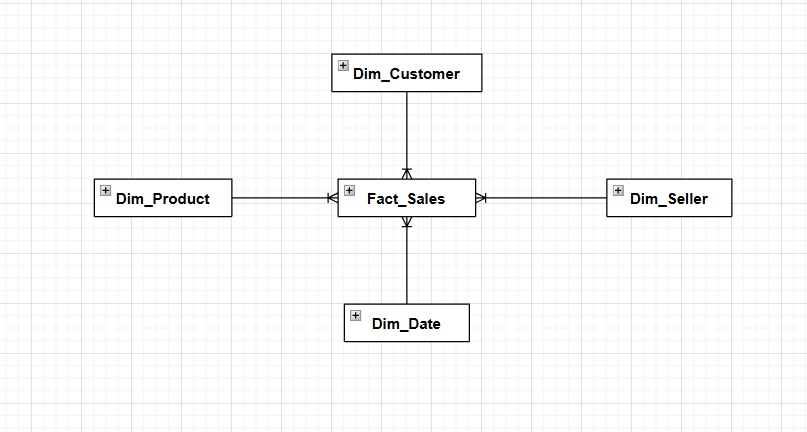

## Data Quality Assessment

### Missing values

In [16]:
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

In [17]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [18]:
geolocation.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [19]:
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [20]:
order_payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [21]:
order_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


Missing values ​​were found in review_comment_title and review_comment_message. These columns are considered irrelevant for the analysis.

In [22]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


The important date for the analysis is order purchase _timestamp, which does not have missing values.

In [23]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


The column product_category_name is relevant for the analysis. I decided to see if every null name has sales.

In [24]:
order_items[
    order_items['product_id'].isin(
        products[products['product_category_name'].isna()]['product_id'])]['product_id'].nunique()

610

All products that do not have a category have sales, therefore they cannot be deleted, instead I assign the Unknown category to them.

In [25]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products['product_category_name'].isna().sum()

np.int64(0)

In [26]:
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [27]:
category.isnull().sum()

,0
product_category_name,0
product_category_name_english,0


### Primary Keys Validations

In [28]:
customers['customer_id'].duplicated().sum()

np.int64(0)

In [29]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [30]:
order_items.duplicated(
    subset = ['order_id', 'order_item_id']
).sum()

np.int64(0)

In [31]:
products['product_id'].duplicated().sum()

np.int64(0)

In [32]:
sellers['seller_id'].duplicated().sum()

np.int64(0)

In [33]:
order_payments.duplicated().sum()

np.int64(0)

In [34]:
order_reviews['review_id'].duplicated().sum()

np.int64(814)

Primary Key Validation

- customers.customer_id → Unique
- orders.order_id → Unique
- products.product_id → Unique
- sellers.seller_id → Unique
- order_items(order_id, order_item_id) → Composite key validated

The review_id table contains duplicate records, so it cannot be considered a reliable primary key.

The table will not be used in the relational model, so this finding does not affect the design.

### Referential Integrity Checks

In [35]:
orders['customer_id'].isin(customers['customer_id']).all()

np.True_

In [36]:
order_items['order_id'].isin(orders['order_id']).all()

np.True_

In [37]:
order_items['product_id'].isin(products['product_id']).all()

np.True_

In [38]:
order_items['seller_id'].isin(sellers['seller_id']).all()

np.True_

In [39]:
order_payments['order_id'].isin(orders['order_id']).all()

np.True_

In [40]:
order_reviews['order_id'].isin(orders['order_id']).all()

np.True_

No orphan records were detected. All foreign keys successfully matched their parent tables.

## Star Schema Design

Fact_Sales: order_id, order_item_id, customer_id, product_id, seller_id, date_id, order_status, price, freight_value

├── Dim_Customer:

customer_id, zip_code, city, state. (I removed the customer_unique_id column)

├── Dim_Product:

product_id, category_name, translation_category_name (as category_name(EN)), photos_qty, weight_g, length_cm, height_cm, width_cm. (I removed the name length and description length columns.)

├── Dim_Seller:

seller_id, zip_code, city, state

└── Dim_Date:

date_id, order_purchase_timestamp (as date), year, month, quarter, week, day_name

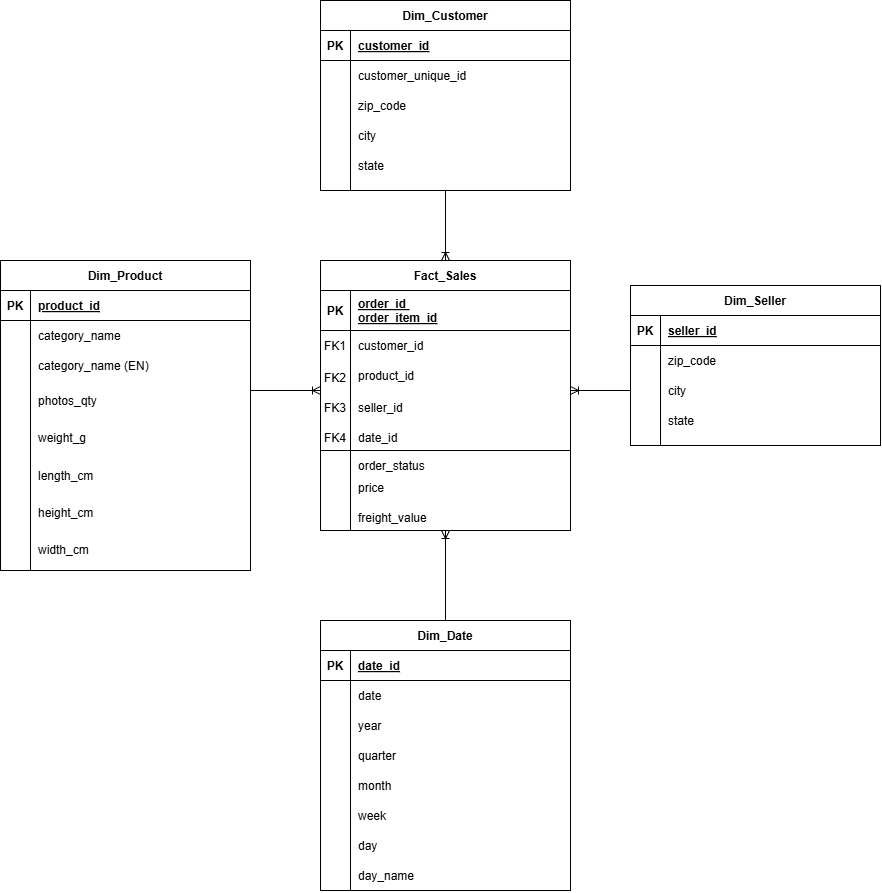

## Design & Dimension Building

### dim_customer

In [41]:
dim_customer = customers.copy()
dim_customer = dim_customer.rename(columns = {'customer_zip_code_prefix':'zip_code', 'customer_city': 'city', 'customer_state':'state'})
dim_customer.head(2)

,customer_id,customer_unique_id,zip_code,city,state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


### dim_seller

In [42]:
dim_seller = sellers.copy()
dim_seller = dim_seller.rename(columns = {'seller_zip_code_prefix': 'zip_code', 'seller_city': 'city', 'seller_state': 'state'})
dim_seller.head(2)

,seller_id,zip_code,city,state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


### dim_product

In [43]:
dim_product = products.copy()
dim_product = dim_product.merge(category, how = 'left', on = 'product_category_name')
dim_product['product_category_name_english'] = dim_product['product_category_name_english'].fillna('Unknown')
dim_product.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art


In [44]:
dim_product = dim_product.rename(columns =
 {'product_category_name': 'category_name', 'product_photos_qty': 'photos_qty',
  'product_weight_g': 'weight_g', 'product_length_cm': 'length_cm', 'product_height_cm': 'height_cm', 'product_width_cm': 'width_cm', 'product_category_name_english': 'category_name(EN)'})
dim_product.head(2)

,product_id,category_name,product_name_lenght,product_description_lenght,photos_qty,weight_g,length_cm,height_cm,width_cm,category_name(EN)
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art


In [45]:
dim_product = dim_product.drop(columns = ['product_name_lenght', 'product_description_lenght'])
dim_product.head(2)

,product_id,category_name,photos_qty,weight_g,length_cm,height_cm,width_cm,category_name(EN)
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,1.0,1000.0,30.0,18.0,20.0,art


### dim_date

In [46]:
orders = orders[
    pd.to_datetime(orders['order_purchase_timestamp']) < '2018-09-01'
] # There are few data after august 2018

In [47]:
dim_date = orders[['order_purchase_timestamp']].copy()
dim_date = dim_date.rename(columns = {'order_purchase_timestamp': 'date'})


In [48]:
dim_date['date'] = pd.to_datetime(dim_date['date']).dt.date
dim_date = dim_date.drop_duplicates()
dim_date = dim_date.reset_index(drop=True)
dim_date.head()

,date
0,2017-10-02
1,2018-07-24
2,2018-08-08
3,2017-11-18
4,2018-02-13


In [49]:
dim_date['date_id'] = (
    pd.to_datetime(dim_date['date'])
    .dt.strftime('%Y%m%d')
    .astype(int)
)

In [50]:
dim_date['year'] = pd.to_datetime(dim_date['date']).dt.year
dim_date['quarter'] = pd.to_datetime(dim_date['date']).dt.quarter
dim_date['month'] = pd.to_datetime(dim_date['date']).dt.month
dim_date['week'] = pd.to_datetime(dim_date['date']).dt.isocalendar().week
dim_date['day'] = pd.to_datetime(dim_date['date']).dt.day
dim_date['day_name'] = pd.to_datetime(dim_date['date']).dt.day_name()
dim_date

,date,date_id,year,quarter,month,week,day,day_name
0,2017-10-02,20171002,2017,4,10,40,2,Monday
1,2018-07-24,20180724,2018,3,7,30,24,Tuesday
2,2018-08-08,20180808,2018,3,8,32,8,Wednesday
3,2017-11-18,20171118,2017,4,11,46,18,Saturday
4,2018-02-13,20180213,2018,1,2,7,13,Tuesday
...,...,...,...,...,...,...,...,...
614,2016-12-23,20161223,2016,4,12,51,23,Friday
615,2017-01-09,20170109,2017,1,1,2,9,Monday
616,2016-10-22,20161022,2016,4,10,42,22,Saturday
617,2016-10-02,20161002,2016,4,10,39,2,Sunday


### Fact_Sales

We need to get the columns

PK: (order_id, order_item_id). From order_items

FK: customer_id from orders, product_id from order_items, seller_id from order_items, date_id from Dim_date

Attributes: order_status from orders

Measures: price and freight_value from order_items

In [51]:
Fact_Sales = order_items.copy()
Fact_Sales = Fact_Sales.merge(orders[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp']], how = 'left', on = 'order_id')
Fact_Sales.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06


In [52]:
Fact_Sales = Fact_Sales.rename(columns = {'order_purchase_timestamp': 'date'})
Fact_Sales['date'] = pd.to_datetime(Fact_Sales['date'])
Fact_Sales.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06


In [53]:
Fact_Sales['date'] = pd.to_datetime(Fact_Sales['date']).dt.date
dim_date['date'] = pd.to_datetime(dim_date['date']).dt.date

In [54]:
Fact_Sales = Fact_Sales.merge(dim_date[['date', 'date_id']], how = 'left', on = 'date')
Fact_Sales

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,date,date_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13,20170913.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,20170426.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,20180114.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,20180808.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,20170204.0
...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23,20180423.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14,20180714.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23,20171023.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14,20170814.0


In [55]:
Fact_Sales = Fact_Sales[['order_id',
        'order_item_id',
        'customer_id',
        'product_id',
        'seller_id',
        'date_id',
        'order_status',
        'price',
        'freight_value']]
Fact_Sales.head()

,order_id,order_item_id,customer_id,product_id,seller_id,date_id,order_status,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,20170913.0,delivered,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,20170426.0,delivered,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,20180114.0,delivered,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,20180808.0,delivered,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,20170204.0,delivered,199.90,18.14


In [56]:
Fact_Sales.isnull().sum()

,0
order_id,0
order_item_id,0
customer_id,1
product_id,0
seller_id,0
date_id,1
order_status,1
price,0
freight_value,0


One record has a missing date_id due to an incomplete purchase timestamp. Since it represents less than 0.01% of the dataset, it was removed from the fact table.

In [57]:
Fact_Sales = Fact_Sales.dropna(subset=['date_id'])
Fact_Sales['date_id'] = Fact_Sales['date_id'].astype(int)

### Data Validations

In [58]:
Fact_Sales.isnull().sum()

,0
order_id,0
order_item_id,0
customer_id,0
product_id,0
seller_id,0
date_id,0
order_status,0
price,0
freight_value,0


In [59]:
dim_customer.isnull().sum()

,0
customer_id,0
customer_unique_id,0
zip_code,0
city,0
state,0


In [60]:
dim_date.isnull().sum()

,0
date,0
date_id,0
year,0
quarter,0
month,0
week,0
day,0
day_name,0


In [61]:
dim_product.isnull().sum()

,0
product_id,0
category_name,0
photos_qty,610
weight_g,2
length_cm,2
height_cm,2
width_cm,2
category_name(EN),0


In [62]:
dim_seller.isnull().sum()

,0
seller_id,0
zip_code,0
city,0
state,0


In [63]:
Fact_Sales.duplicated(subset = ['order_id', 'order_item_id']).sum()

np.int64(0)

In [64]:
dim_customer.duplicated().sum()

np.int64(0)

In [65]:
dim_date.duplicated().sum()

np.int64(0)

In [66]:
dim_product.duplicated().sum()

np.int64(0)

In [67]:
dim_seller.duplicated().sum()

np.int64(0)

Issue detected

The initial Date Dimension generated duplicated keys because date_id was created using only YYYYMMDD while timestamps contained multiple records per day.

Solution

The dimension was rebuilt using unique calendar dates before generating date_id.

## Export

Fact_Sales | Dim_customer | Dim_produdct | Dim_seller | Dim_date

In [ ]:
Fact_Sales.to_csv('Fact_Sales.csv', index = False)
dim_customer.to_csv('Dim_customer.csv', index = False)
dim_product.to_csv('Dim_product.csv', index = False)
dim_seller.to_csv('Dim_seller.csv', index = False)
dim_date.to_csv('Dim_date.csv', index = False)

The cleaned dimensional model was exported as CSV files and later imported into PostgreSQL for analytical querying and Power BI visualization.

## Business Questions

1. How much does the platform sell?
2. How do sales evolve over time?
3. Which categories generate the most revenue?
4. Which states buy the most?
5. Who are the top sellers?
6. Who are the most frequent customers?
7. Which product categories are the most requested?
8. What percentage of products have been canceled, and which category has the most cancellations?

## Conclusion

This project successfully built an end-to-end analytical pipeline including

- Data Cleaning
- ETL
- Dimensional Modeling
- PostgreSQL
- Power BI Dashboard